In [1]:
import sys

sys.path.append("..")

In [2]:
import os
import pickle
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [38]:
# from analysis.utils.visualization_fn import (
#     plot_age_histogram, plot_age_by_group, plot_age_vs_sex,
#     plot_intensity_histogram, show_mid_slice
# )
from analysis.utils.visualization_fn import (
    plot_age_by_group,
    plot_age_histogram,
    plot_age_vs_sex,
    plot_intensity_histogram,
    show_mid_slice,
)

In [4]:
# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [5]:
# Paths
IXI_BASE = "../data/raw/ixi/IXI_data/IXI_data"
IXI_CSV = "../data/raw/ixi/IXI_processed.csv"

In [6]:
meta_df = pd.read_csv(IXI_CSV)
print(f"Total subjects in CSV: {len(meta_df)}")
meta_df.head()

Total subjects in CSV: 587


,Subject_ID,"SEX_ID (1=m, 2=f)",HEIGHT,WEIGHT,ETHNIC_ID,MARITAL_ID,OCCUPATION_ID,QUALIFICATION_ID,DOB,DATE_AVAILABLE,STUDY_DATE,AGE
0,0,2,164,58,1,4,1,5,1/30/1970,1,11/18/2005,35.800137
1,1,1,175,70,1,2,1,5,8/20/1966,1,6/1/2005,38.781656
2,2,1,182,70,1,2,1,5,9/15/1958,1,6/1/2005,46.710472
3,3,2,163,65,1,4,1,5,3/15/1971,1,6/9/2005,34.236824
4,4,1,181,90,2,1,6,5,3/11/1981,1,6/23/2005,24.284736


In [7]:
meta_df.rename(
    columns={"Subject_ID": "subject_id", "SEX_ID (1=m, 2=f)": "sex_code", "AGE": "age"},
    inplace=True,
)
meta_df["sex"] = meta_df["sex_code"].map({1: "Male", 2: "Female"})

In [8]:
meta_df.columns

Index(['subject_id', 'sex_code', 'HEIGHT', 'WEIGHT', 'ETHNIC_ID', 'MARITAL_ID',
       'OCCUPATION_ID', 'QUALIFICATION_ID', 'DOB', 'DATE_AVAILABLE',
       'STUDY_DATE', 'age', 'sex'],
      dtype='object')

In [9]:
meta_df.head()

,subject_id,sex_code,HEIGHT,WEIGHT,ETHNIC_ID,MARITAL_ID,OCCUPATION_ID,QUALIFICATION_ID,DOB,DATE_AVAILABLE,STUDY_DATE,age,sex
0,0,2,164,58,1,4,1,5,1/30/1970,1,11/18/2005,35.800137,Female
1,1,1,175,70,1,2,1,5,8/20/1966,1,6/1/2005,38.781656,Male
2,2,1,182,70,1,2,1,5,9/15/1958,1,6/1/2005,46.710472,Male
3,3,2,163,65,1,4,1,5,3/15/1971,1,6/9/2005,34.236824,Female
4,4,1,181,90,2,1,6,5,3/11/1981,1,6/23/2005,24.284736,Male


In [10]:
def get_split_subjects(split_dir):
    pkl_files = glob(os.path.join(IXI_BASE, split_dir, "*.pkl"))
    subjects = []
    for f in pkl_files:
        # Extract number from "subject_327.pkl"
        fname = os.path.basename(f)
        num_str = fname.split("_")[-1].replace(".pkl", "")
        subjects.append(int(num_str))
    return subjects

In [11]:
train_subjects = get_split_subjects("Train")
val_subjects = get_split_subjects("Val")
test_subjects = get_split_subjects("Test")

In [12]:
print(f"Train: {len(train_subjects)}, Val: {len(val_subjects)}, Test: {len(test_subjects)}")

Train: 403, Val: 58, Test: 115


In [13]:
# Add split column
meta_df["split"] = "unknown"
meta_df.loc[meta_df["subject_id"].isin(train_subjects), "split"] = "train"
meta_df.loc[meta_df["subject_id"].isin(val_subjects), "split"] = "val"
meta_df.loc[meta_df["subject_id"].isin(test_subjects), "split"] = "test"

In [14]:
# Check for missing
missing = meta_df[meta_df["split"] == "unknown"]
print(f"Subjects in CSV but not in any split folder: {len(missing)}")
meta_df["split"].value_counts()

Subjects in CSV but not in any split folder: 1


split
train      412
test       113
val         61
unknown      1
Name: count, dtype: int64

In [15]:
meta_df.columns

Index(['subject_id', 'sex_code', 'HEIGHT', 'WEIGHT', 'ETHNIC_ID', 'MARITAL_ID',
       'OCCUPATION_ID', 'QUALIFICATION_ID', 'DOB', 'DATE_AVAILABLE',
       'STUDY_DATE', 'age', 'sex', 'split'],
      dtype='object')

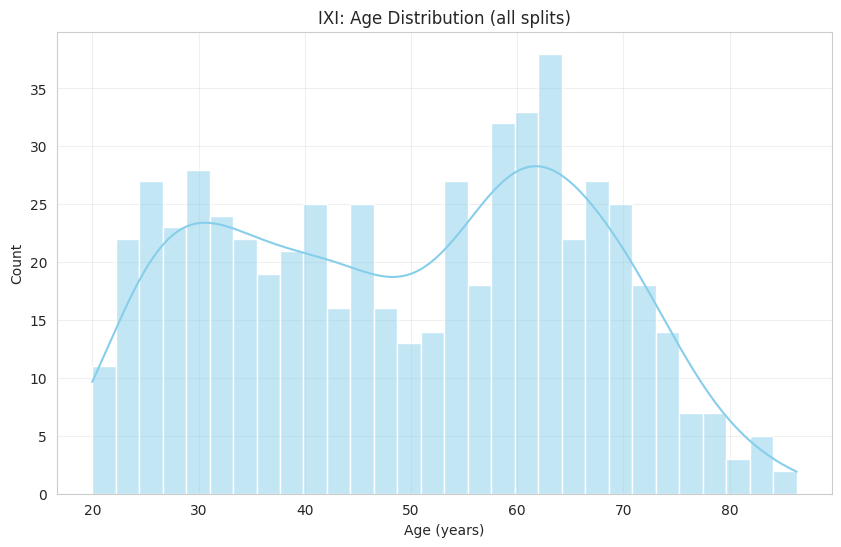

In [16]:
plot_age_histogram(
    meta_df["age"],
    title="IXI: Age Distribution (all splits)",
    save_path="../analysis/figures/ixi_age_all.png",
)

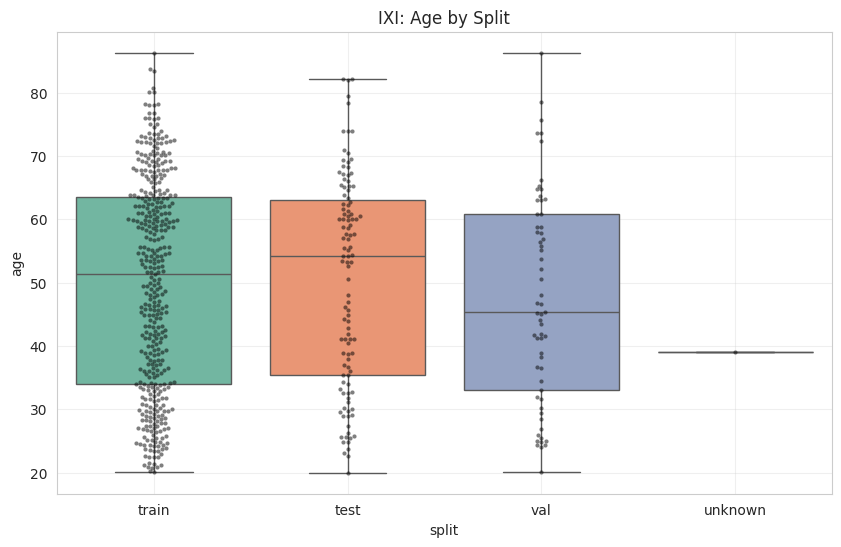

In [17]:
plot_age_by_group(
    meta_df,
    age_col="age",
    group_col="split",
    title="IXI: Age by Split",
    save_path="../analysis/figures/ixi_age_by_split.png",
)

sex
Female    327
Male      260
Name: count, dtype: int64


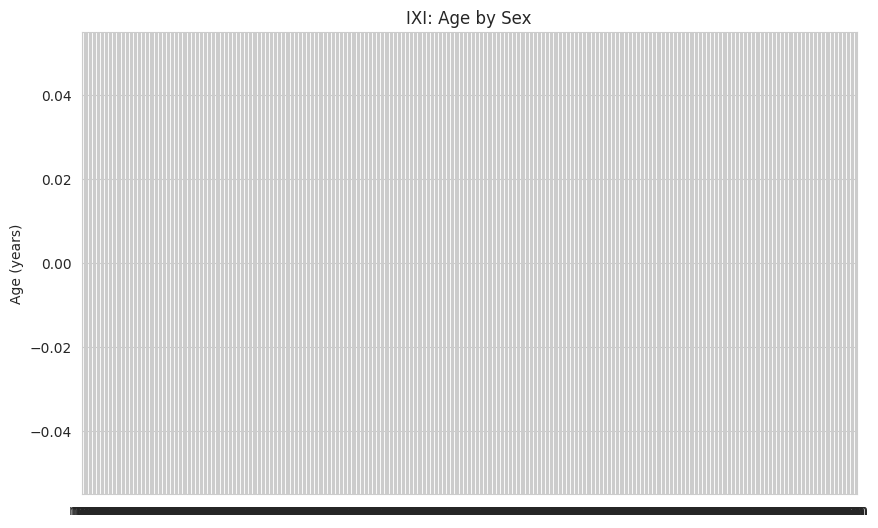

In [18]:
# Sex Distribution
# Map SEX code: 1=M, 2=F (common in IXI)
sex_counts = meta_df["sex"].value_counts()
print(sex_counts)
meta_df["sex_label"] = meta_df["sex"].map({1: "Male", 2: "Female"})
plot_age_vs_sex(
    meta_df["age"],
    meta_df["sex_label"],
    title="IXI: Age by Sex",
    save_path="../analysis/figures/ixi_age_by_sex.png",
)

In [32]:
def load_pkl(subject_id, split):
    pkl_path = os.path.join(IXI_BASE, split, f"subject_{subject_id}.pkl")
    with open(pkl_path, "rb") as f:
        image, label = pickle.load(f)
    return {"image": image, "label": label}

In [33]:
sample_train = train_subjects[0]
sample_val = val_subjects[0]
sample_test = test_subjects[0]

In [34]:
# Load sample
data_train = load_pkl(sample_train, "Train")
print("Image shape:", data_train["image"].shape)
print("Label shape:", data_train["label"].shape)

Image shape: (160, 192, 224)
Label shape: (160, 192, 224)


/tmp/ipykernel_940804/3945199545.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  image, label = pickle.load(f)


In [35]:
# Get age and sex from metadata
age = meta_df.loc[meta_df["subject_id"] == sample_train, "age"].values[0]
sex = meta_df.loc[meta_df["subject_id"] == sample_train, "sex"].values[0]
print(f"Age: {age}, Sex: {sex}")

Age: 29.25667351, Sex: Male


In [28]:
data_train = load_pkl(sample_train, "Train")
data_val = load_pkl(sample_val, "Val")
data_test = load_pkl(sample_test, "Test")

print("Train sample keys:", data_train)
print("Image shape:", data_train["image"].shape)
print("Label shape:", data_train["label"].shape)
print("Age:", data_train["age"])
print("Sex:", data_train["sex"])

Type: <class 'tuple'>
Tuple length: 2
  Item 0: shape = (160, 192, 224)
  Item 1: shape = (160, 192, 224)
Type: <class 'tuple'>
Tuple length: 2
  Item 0: shape = (160, 192, 224)
  Item 1: shape = (160, 192, 224)
Type: <class 'tuple'>
Tuple length: 2
  Item 0: shape = (160, 192, 224)
  Item 1: shape = (160, 192, 224)
Train sample keys: (array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 

/tmp/ipykernel_940804/2145149779.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f)


TypeError: tuple indices must be integers or slices, not str

Min: 0.0000, Max: 0.9176, Mean: 0.1094, Std: 0.1639


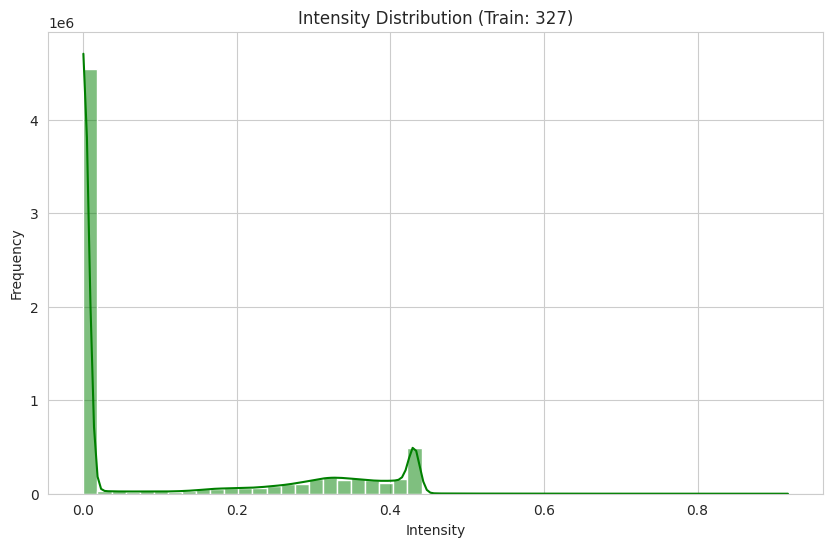

In [36]:
img = data_train["image"]
print(f"Min: {img.min():.4f}, Max: {img.max():.4f}, Mean: {img.mean():.4f}, Std: {img.std():.4f}")
plot_intensity_histogram(
    img,
    title=f"Intensity Distribution (Train: {sample_train})",
    save_path="../analysis/figures/ixi_intensity_train.png",
)

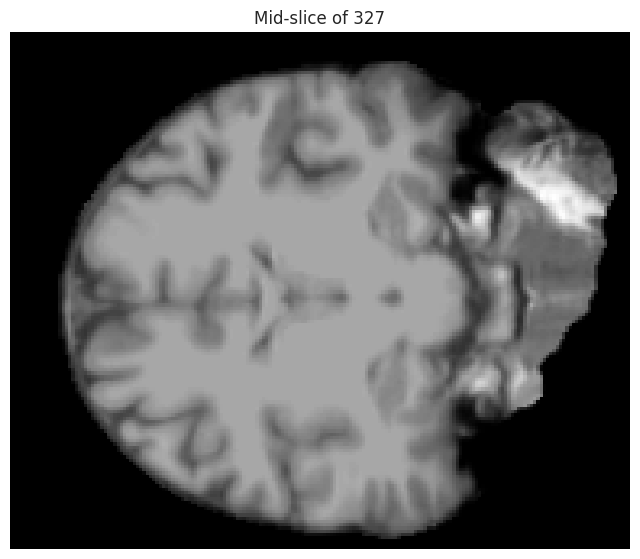

In [39]:
show_mid_slice(
    img,
    title=f"Mid-slice of {sample_train}",
    save_path="../analysis/figures/ixi_mid_slice_train.png",
)

In [40]:
common_train_val = set(train_subjects) & set(val_subjects)
common_train_test = set(train_subjects) & set(test_subjects)
common_val_test = set(val_subjects) & set(test_subjects)
print(f"Overlap Train-Val: {len(common_train_val)}")
print(f"Overlap Train-Test: {len(common_train_test)}")
print(f"Overlap Val-Test: {len(common_val_test)}")

Overlap Train-Val: 0
Overlap Train-Test: 0
Overlap Val-Test: 0


In [41]:
summary = meta_df.groupby("split")["age"].describe()
summary

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,111.0,50.307515,16.518171,19.980835,35.430527,54.193018,63.077344,82.187543
train,411.0,49.695376,16.757859,20.071184,34.034223,51.290897,63.601643,86.318960
unknown,1.0,39.022587,NaN,39.022587,39.022587,39.022587,39.022587,39.022587
val,61.0,47.506244,16.557422,20.167009,33.078713,45.388090,60.895277,86.198494


In [42]:
meta_df.to_csv("../data/processed/ixi_metadata_with_splits.csv", index=False)
print("Saved metadata to data/processed/ixi_metadata_with_splits.csv")

Saved metadata to data/processed/ixi_metadata_with_splits.csv
